In [1]:
import jax.numpy as jnp
import numpy as np
from matplotlib import pyplot as plt
import scanpy as sc
import pandas as pd
import seaborn as sns
from gstatot import sweep_utils, utils
import os
from matplotlib.collections import LineCollection

sns.set_context("paper", font_scale=1.5)
sns.set_theme(style="ticks")

In [2]:
# generate this data using the other notebooks in this directory.
gSOT_traj_100 = np.load('./gSOT_traj_100.npy')
gSOT_traj_2 = np.load('./gSOT_traj_2.npy') 
gWOT_traj = np.load('./gWOT_traj.npy')
adata = sc.read('./time_course_methods_comp.h5ad')

In [3]:
def  plot_trajectories(paths_growth, ax, times, cmap='viridis', data_points = None, colorbar=True, cbar_label='Progression'):
    
    N_path, traj_len, dim = paths_growth.shape
    paths = paths_growth
    progression = np.linspace(times.min(), times.max(), traj_len)
    if data_points is not None:
        ax.scatter(data_points[:, 0], data_points[:, 1], color='grey', s=20, label='Data Points', alpha=0.5)

    for i in range(N_path):
        x = paths[i, :, 0]
        y = paths[i, :, 1]

        points = np.array([x, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)

        norm = plt.Normalize(progression.min(), progression.max())
        lc = LineCollection(segments, cmap=cmap, norm=norm, alpha = 0.5)

        lc.set_array(progression)
        lc.set_linewidth(2)

        ax.add_collection(lc)

    ax.set_xlim(-0.35, 3.5)
    ax.set_ylim(-0.5, 3)
#    ax.set_xticks([])
#    ax.set_yticks([])

    if colorbar:
        cbar = plt.colorbar(lc, ax=ax)
        cbar.set_label(cbar_label)
        cbar.solids.set_alpha(1)
    

Trajectory length: 172, dt: 0.01, total time: 1.72, number of trajectories: 100


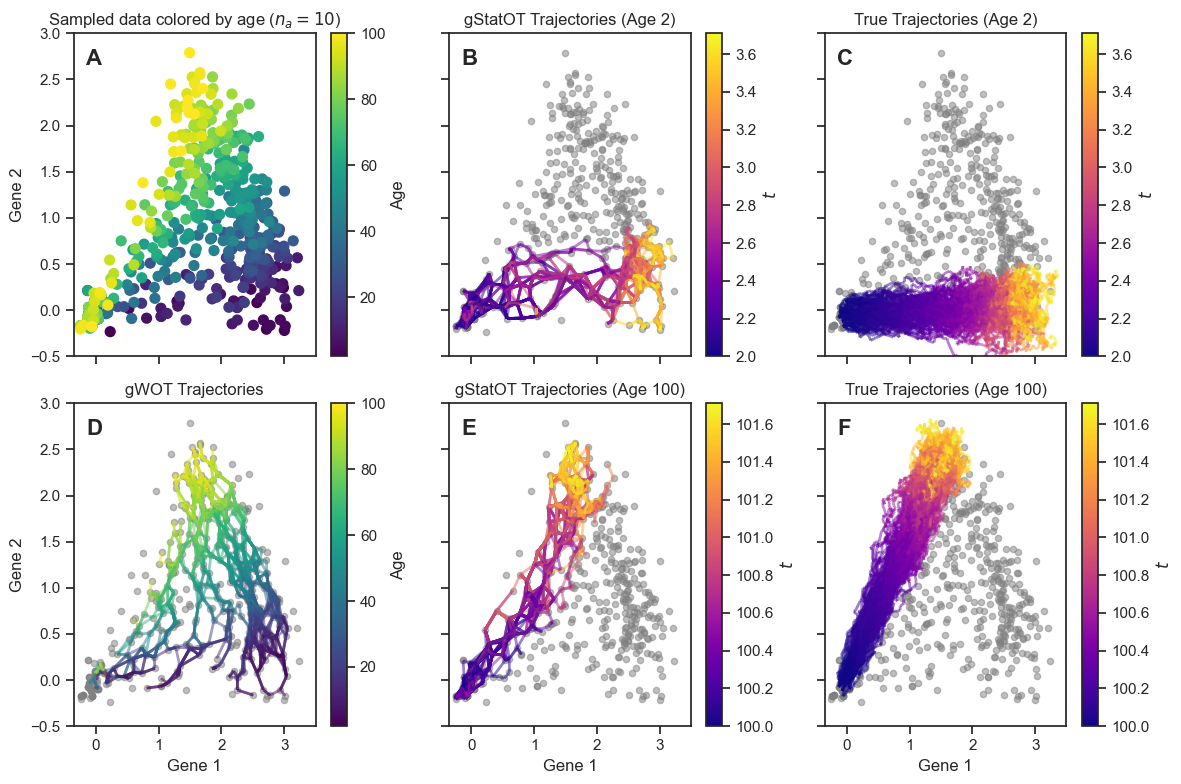

In [4]:
# Data by age, gSOT traj age 2, true traj age 2
# gWOT traj , gSOT traj age 100, true traj age 100
layout = """
    ABC
    DEF
"""
dt = adata.uns['true_dt']
num_gSOT_traj = gSOT_traj_2.shape[0]
traj_len = gSOT_traj_2.shape[1]
true_traj_2 = adata.uns['true_traj_data']['2.0'][:num_gSOT_traj, :traj_len, :]
true_traj_100 = adata.uns['true_traj_data']['100.0'][:num_gSOT_traj, :traj_len, :]
print(f"Trajectory length: {traj_len}, dt: {dt}, total time: {traj_len*dt}, number of trajectories: {num_gSOT_traj}")

fig, ax = plt.subplot_mosaic(layout, figsize=(12, 8), sharex=True, sharey=True)
data = adata.obsm['X_pca'][:, :2]

ax['A'].scatter(data[:, 0], data[:, 1], c=adata.obs['chronological_age'], cmap='viridis', s=50, alpha=1)
cbar = plt.colorbar(ax['A'].collections[0], ax=ax['A'])
cbar.set_label(r'Age')
ax['A'].set_title(r'Sampled data colored by age ($n_a = 10$)')
ax['A'].set_ylabel('Gene 2')
ax['A'].text(0.05, 0.95, 'A', transform=ax['A'].transAxes, fontsize=16, fontweight='bold', va='top', ha='left')

plot_trajectories(gSOT_traj_2, ax['B'], np.arange(2.0, 2.0 + traj_len*dt, dt), cmap='plasma', data_points=data, cbar_label=r'$t$')
ax['B'].text(0.05, 0.95, 'B', transform=ax['B'].transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
ax['B'].set_title('gStatOT Trajectories (Age 2)')

plot_trajectories(true_traj_2, ax['C'], np.arange(2.0, 2.0 + traj_len*dt, dt), cmap='plasma', data_points=data, cbar_label=r'$t$')
ax['C'].text(0.05, 0.95, 'C', transform=ax['C'].transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
ax['C'].set_title('True Trajectories (Age 2)')

plot_trajectories(gWOT_traj, ax['D'], np.unique(adata.obs['chronological_age']), data_points=data, cbar_label=r'Age')
ax['D'].text(0.05, 0.95, 'D', transform=ax['D'].transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
ax['D'].set_title('gWOT Trajectories')
ax['D'].set_xlabel('Gene 1')
ax['D'].set_ylabel('Gene 2')

plot_trajectories(gSOT_traj_100, ax['E'], np.arange(100.0, 100.0 + traj_len*dt, dt), cmap='plasma', data_points=data, cbar_label=r'$t$')
ax['E'].text(0.05, 0.95, 'E', transform=ax['E'].transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
ax['E'].set_title('gStatOT Trajectories (Age 100)')
ax['E'].set_xlabel('Gene 1')
# remove colorbar for this subplot

plot_trajectories(true_traj_100, ax['F'], np.arange(100.0, 100.0 + traj_len*dt, dt), cmap='plasma', data_points=data, cbar_label=r'$t$')
ax['F'].text(0.05, 0.95, 'F', transform=ax['F'].transAxes, fontsize=16, fontweight='bold', va='top', ha='left')
ax['F'].set_title('True Trajectories (Age 100)')
ax['F'].set_xlabel('Gene 1')
plt.tight_layout()
plt.savefig('../figures/plots/gWOT_gSOT_comparison.pdf', dpi=300)